# 載入資料集

In [13]:
from tensorflow.keras.datasets import cifar10

(X_train_image, y_train_label), (X_test_image, y_test_label) = cifar10.load_data()

In [14]:
# 查看資料
print(type(X_train_image))
print(type(y_train_label))

print(X_train_image.shape) #　(50000, 32, 32, 3)，50000筆 32x32的影像 RGB三原色
print(y_train_label.shape) # 50000標籤
print(X_test_image.shape)
print(y_test_label.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
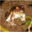

In [15]:
X_train_image[0]

In [16]:
# reshape 轉成1維
y_train_label = y_train_label.reshape(-1)
y_test_label = y_test_label.reshape(-1)

print(y_train_label.shape)
print(y_test_label.shape)
print(y_test_label[1])

(50000,)
(10000,)
8


# 查看多筆資料

In [17]:
import matplotlib.pyplot as plt

label_dict = {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

def plot_images_labels_prediction(images, labels, prediction, idx, num=10):
    fig = plt.gcf()
    fig.set_size_inches(12, 14)
    if num > 25: num = 25
    for i in range(0, num):
        ax = plt.subplot(5, 5, i+1)
        ax.imshow(images[idx], cmap='binary')
        title = "label=" + str(label_dict[labels[idx]])
        if len(prediction) > 0:
            title += ", predict=" + str(label_dict[prediction[idx]])
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        idx += 1
    plt.show()

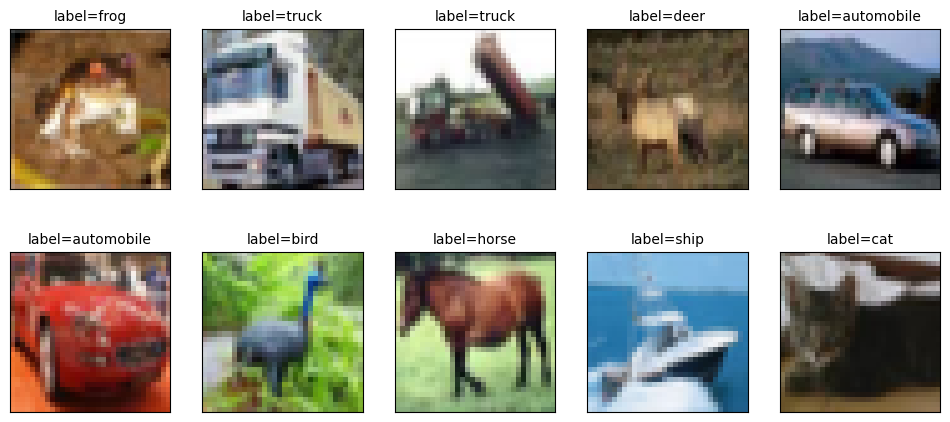

In [18]:
plot_images_labels_prediction(X_train_image, y_train_label, [], 0, 10)

# 資料預處理

In [19]:
# 進行標準化
X_train_normalize = X_train_image.astype('float32') / 255.0
X_test_normalize = X_test_image.astype('float32') / 255.0

# 轉換前後差異
X_train_image[0][0][0] # 訓練資料第0個影像的第0個點
X_train_normalize[0][0][0] # 標準化之後數字介於0~1

array([0.23137255, 0.24313726, 0.24705882], dtype=float32)

In [20]:
# One-hot Encoding處理
from tensorflow.keras import utils

y_train_onehot = utils.to_categorical(y_train_label)
y_test_onehot = utils.to_categorical(y_test_label)

# 轉換前後差異
print(y_train_label[0]) # 訓練標籤第0筆
print(y_train_onehot[0]) # 由0算起第6個位置是1，其餘都是0

6
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
